# London Airbnb Analysis — Sentiment Analysis (TextBlob)

This notebook runs sentiment analysis on 10,000 sampled London Airbnb reviews using TextBlob. 

TextBlob assigns a polarity score between -1 and 1 to each review:
- **Positive** = score above 0
- **Neutral** = score of 0  
- **Negative** = score below 0

See `05_sentiment_vader.ipynb` for the VADER analysis and `06_sentiment_comparison.ipynb` for a comparison of both methods.

## 1. Import Libraries

In [15]:
# Import libraries
import pandas as pd
from textblob import TextBlob

print("Libraries loaded!")

Libraries loaded!


## 2. Load Reviews

In [16]:
# Load the cleaned reviews data
reviews = pd.read_csv('../data/reviews_clean.csv')

print("Reviews loaded!")
print("Rows:", len(reviews))

/var/folders/2j/d77yjnh176bbf7pmhw8lt2zc0000gq/T/ipykernel_73635/3855834746.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv('../data/reviews_clean.csv')


Reviews loaded!
Rows: 2111024


In [17]:
# Sample 10,000 reviews - running on all 2 million would take too long
reviews_sample = reviews.sample(10000, random_state=42)

print("Sample size:", len(reviews_sample))

Sample size: 10000


## 3. Test TextBlob

Before running on the full dataset, we will test TextBlob on some simple examples to understand how it works.

In [18]:
# Test TextBlob on a positive sentence
review1 = "This place was absolutely amazing, loved every minute!"
score1 = TextBlob(review1).sentiment.polarity
print("Review:", review1)
print("Score:", score1)

Review: This place was absolutely amazing, loved every minute!
Score: 0.7375


In [19]:
# Test on a negative sentence
review2 = "Terrible experience, very dirty and noisy."
score2 = TextBlob(review2).sentiment.polarity
print("Review:", review2)
print("Score:", score2)

Review: Terrible experience, very dirty and noisy.
Score: -0.89


In [20]:
# Test on a neutral sentence
review3 = "The room was a room."
score3 = TextBlob(review3).sentiment.polarity
print("Review:", review3)
print("Score:", score3)

Review: The room was a room.
Score: 0.0


In [21]:
# Test on a real review from our dataset
real_review = reviews_sample['comments'].iloc[0]
score4 = TextBlob(str(real_review)).sentiment.polarity
print("Review:", real_review[:200])
print("Score:", score4)

Review: affordable and well furnished! good stay!
Score: 0.875


## 4. Run Sentiment Analysis on Sample

In [22]:
# Run sentiment analysis on each review in the sample
reviews_sample['polarity'] = reviews_sample['comments'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

print("Done!")
print(reviews_sample['polarity'].describe())

Done!
count    10000.000000
mean         0.358512
std          0.247176
min         -1.000000
25%          0.215000
50%          0.365026
75%          0.500000
max          1.000000
Name: polarity, dtype: float64


In [23]:
# Classify each review as positive, neutral or negative
def get_sentiment(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

reviews_sample['sentiment'] = reviews_sample['polarity'].apply(get_sentiment)

print("Sentiment counts:")
print(reviews_sample['sentiment'].value_counts())

Sentiment counts:
sentiment
positive    8418
neutral     1404
negative     178
Name: count, dtype: int64


## 5. Visualise Results

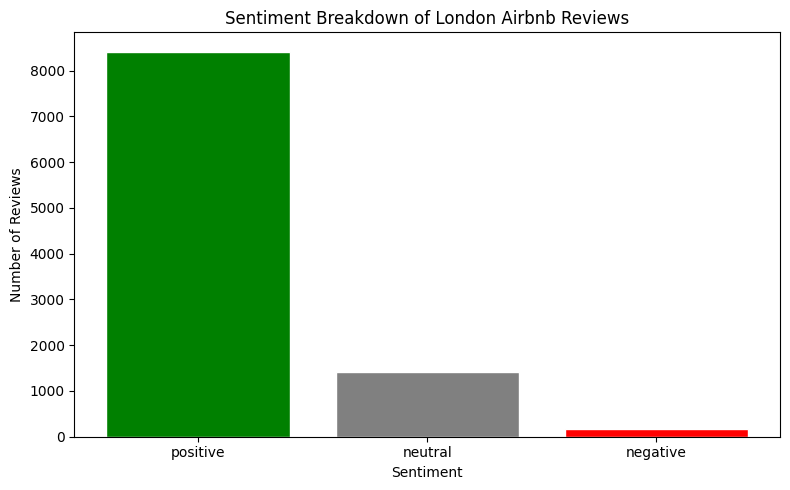

In [24]:
# Plot the sentiment breakdown
import matplotlib.pyplot as plt

sentiment_counts = reviews_sample['sentiment'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'grey', 'red'], edgecolor='white')
plt.title('Sentiment Breakdown of London Airbnb Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

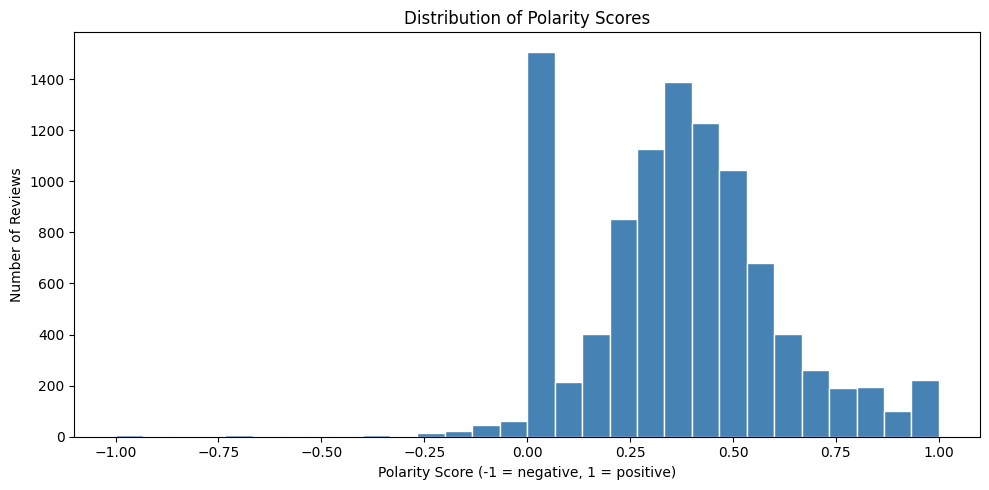

In [25]:
# Plot the distribution of polarity scores
plt.figure(figsize=(10, 5))
plt.hist(reviews_sample['polarity'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Polarity Scores')
plt.xlabel('Polarity Score (-1 = negative, 1 = positive)')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

## 6. Save Results

In [26]:
# Save the TextBlob sentiment results
reviews_sample.to_csv('../data/reviews_textblob.csv', index=False)

print("TextBlob results saved!")

TextBlob results saved!


## 7. Summary

Key findings from TextBlob sentiment analysis on 10,000 sampled London Airbnb reviews:

- **84% positive** — the vast majority of guests had a good experience
- **14% neutral** — factual reviews with no strong positive or negative language
- **2% negative** — very few guests left negative reviews
- **Average polarity score: 0.36** — overall strongly positive sentiment
- The polarity distribution is right-skewed, confirming London Airbnb guests are generally satisfied

**Limitation of TextBlob:**
TextBlob uses a simple dictionary lookup and does not handle exclamation marks, capitals or informal language well. See the VADER notebook for a more accurate analysis.